<a href="https://colab.research.google.com/github/katg05403-oss/Customer-Churn-Prediction/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
blastchar_telco_customer_churn_path = kagglehub.dataset_download('blastchar/telco-customer-churn')

print('Data source import complete.')


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Data source import complete.


In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
#Loading the dataset
df = pd.read_csv("/content/archive (6).zip")

In [10]:
#Basic exploration
print("The number of rows and columns is",df.shape)

The number of rows and columns is (7043, 21)


In [11]:
print("Statistical Summary",df.describe())

Statistical Summary        SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [12]:
print("Data types of features is", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


#### problem:here the datatype of total charges is object.  

In [13]:
print("Checking the null values in data ",df.isnull().sum())

Checking the null values in data  customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [14]:
#check target distribution
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


####  Typically around 73% No Churn vs 27% Churn   

In [15]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Exploratory Data Analysis

<Axes: xlabel='Churn', ylabel='count'>

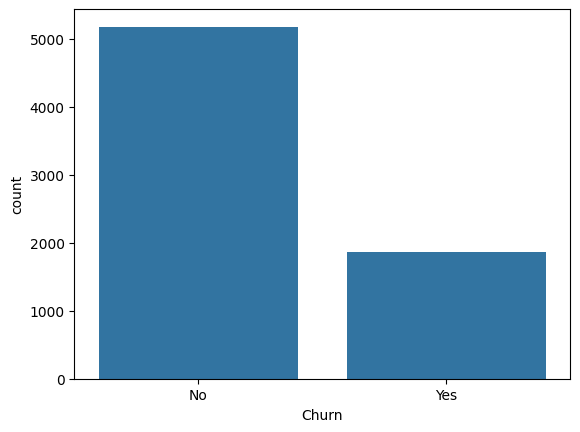

In [16]:
#Churn Distribution
sns.countplot(x="Churn",data= df)

<Axes: xlabel='Contract', ylabel='count'>

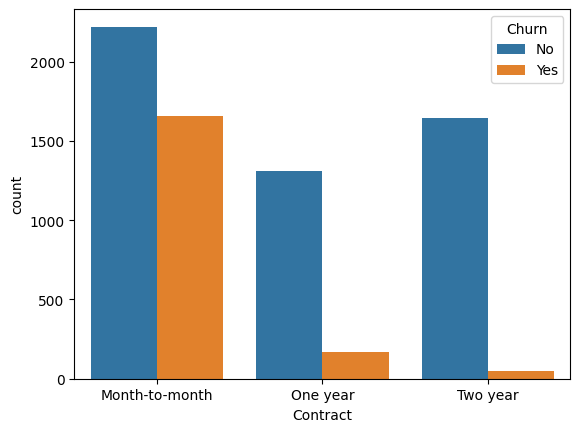

In [17]:
#Churn vs Contract Type
sns.countplot(x='Contract',hue='Churn',data=df)

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

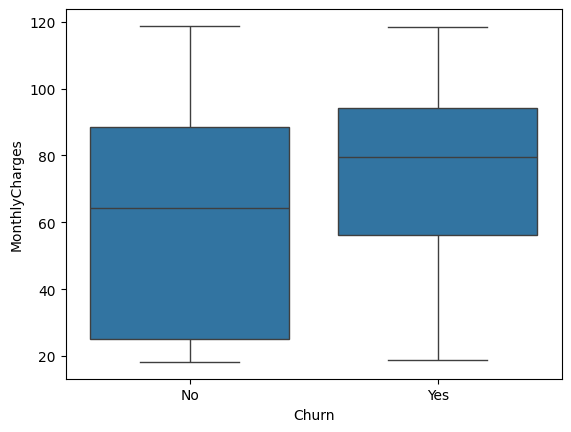

In [18]:
#Churn Vs Monthly Charges
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)

<Axes: >

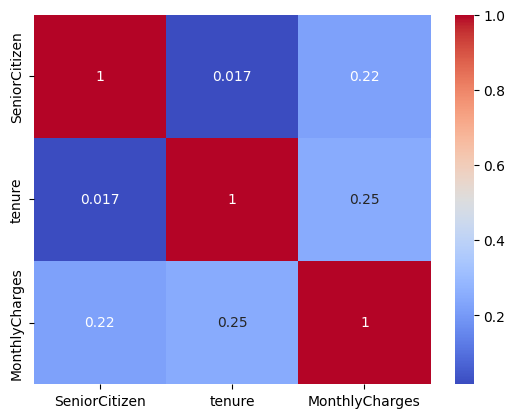

In [19]:
#Correlation heatmap for numerical features
sns.heatmap(df.select_dtypes(include='number').corr(),annot=True,cmap='coolwarm')

<Axes: xlabel='tenure', ylabel='Count'>

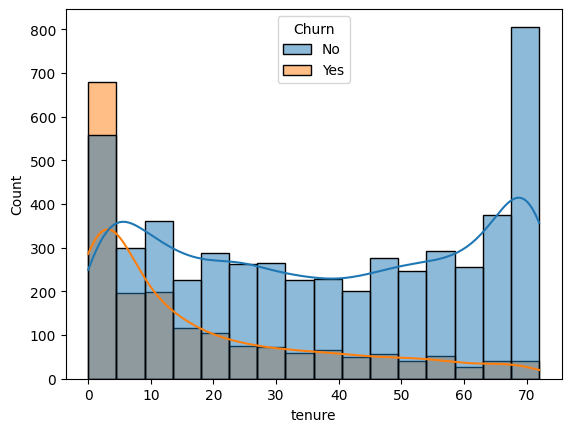

In [20]:
#Churn Vs tenure
sns.histplot(data=df,x='tenure',hue='Churn',kde=True )

# Data Preprocessing

In [21]:
#Dropping the customerID as it is not useful
df.drop('customerID',axis=1,inplace=True)

In [22]:
#Fix TotalCharges columns which is object type
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'],errors='coerce')
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

/tmp/ipykernel_6076/1899954454.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [24]:
#Encode target variable
df['Churn'] = df['Churn'].map({'Yes':1,'No':0})

In [25]:
df['Churn']

,Churn
0,0
1,0
2,1
3,0
4,1
...,...
7038,0
7039,0
7040,0
7041,1


In [26]:
#Encode categorical features
df = pd.get_dummies(df,drop_first=True)

In [27]:
df

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,0,True,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,0,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,0,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,1,True,True,False,True,False,...,False,False,False,False,False,False,True,False,False,True


# Handle Class Imbalance Using SMOTE

In [28]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

In [29]:
X= df.drop('Churn',axis=1)
y= df['Churn']

In [30]:
#Checking imbalance before Smote
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


#### Typically around 73% No Churn vs 27% Churn   

In [32]:
#Performing train test split
X_train, X_test , y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [33]:
#Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_smote,y_train_smote = smote.fit_resample(X_train,y_train)

In [34]:
#Check balance after smote
print(pd.Series(y_train_smote).value_counts())

Churn
0    4139
1    4139
Name: count, dtype: int64


# Feature Scaling

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

# Built the Classificatiion Model

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Baseline model
lr = LogisticRegression(random_state=42)
lr.fit(X_train_scaled, y_train_smote)
lr_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, lr_pred))

# Random Forest for feature importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train_smote)
rf_pred = rf.predict(X_test_scaled)
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83      1035
           1       0.54      0.63      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.71      1409
weighted avg       0.77      0.76      0.77      1409

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.78      1409



# Visualize Confusion Matrix

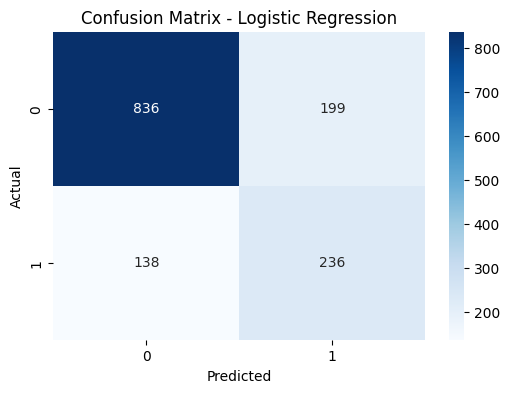

In [37]:
from sklearn.metrics import confusion_matrix
# Create confusion matrix for logistic Regression
cm_lr = confusion_matrix(y_test,lr_pred)
#Plot heat map
plt.figure(figsize=(6,4))
sns.heatmap(cm_lr,
            annot = True,
             fmt='d',
             cmap ='Blues'
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

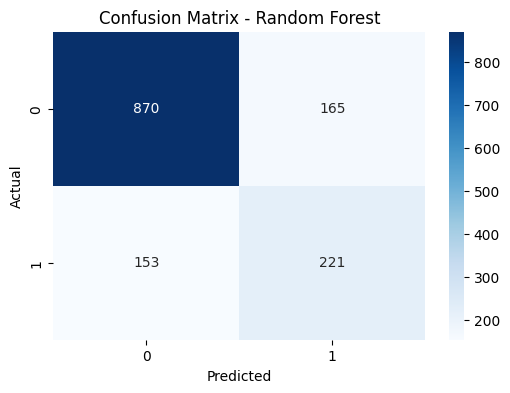

In [38]:
# Create confusion matrix for logistic Regression
cm_rf = confusion_matrix(y_test,rf_pred)
#Plot heat map
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf,
            annot = True,
             fmt='d',
             cmap ='Blues'
            )
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()

#  Precision Recall Curve

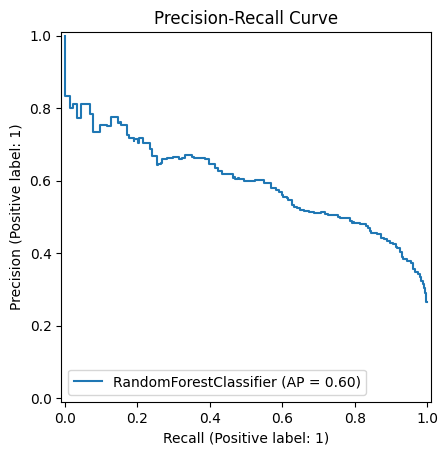

In [39]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_estimator(rf, X_test_scaled, y_test)
plt.title('Precision-Recall Curve')
plt.show()

#  Feature Importance Plot

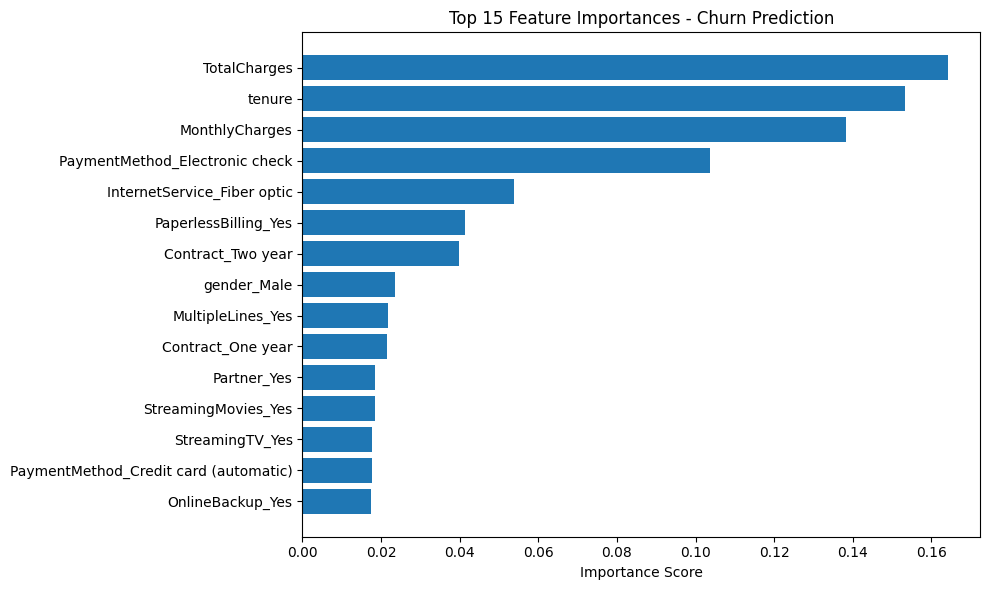

In [40]:
# Get feature importances from Random Forest
feature_names = X.columns
importances = rf.feature_importances_

# Sort by importance
indices = np.argsort(importances)[::-1][:15]  # top 15 features

plt.figure(figsize=(10, 6))
plt.title('Top 15 Feature Importances - Churn Prediction')
plt.barh(range(15), importances[indices][::-1], align='center')
plt.yticks(range(15), [feature_names[i] for i in indices][::-1])
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

#  Measure the 18% Recall Improvement

In [41]:
from sklearn.metrics import recall_score

# Model WITHOUT SMOTE
rf_no_smote = RandomForestClassifier(random_state=42)
rf_no_smote.fit(X_train, y_train)
pred_no_smote = rf_no_smote.predict(X_test)
recall_before = recall_score(y_test, pred_no_smote)

# Model WITH SMOTE
recall_after = recall_score(y_test, rf_pred)

improvement = ((recall_after - recall_before) / recall_before) * 100
print(f"Recall before SMOTE: {recall_before:.2f}")
print(f"Recall after SMOTE:  {recall_after:.2f}")
print(f"Improvement: {improvement:.1f}%")

Recall before SMOTE: 0.49
Recall after SMOTE:  0.59
Improvement: 20.1%
